# Voigt Profile Fitting on Stacked RRL Spectra

This notebook fits Voigt profiles on stacked Carbon Radio Recombination Line (RRL) spectra produced by `3_Stacking`.  **It reads stack files from disk and does not recompute them.**

## How to use this notebook

**Edit the `⚙️ 1 — Configuration` cell.** Everything else runs automatically.  
> ⚠️  Run `3_Stacking` first to generate the `.txt` stack files.

---

## Pipeline overview

| Step | What it does |
|------|--------------|
| 1 | **Configuration** — set source, comparison pointings, and fitting parameters |
| 2 | **Imports** — load libraries (no editing needed) |
| 3 | **Load stacks** — read all stack files from disk |
| 4 | **Voigt fit functions** — define multi-component helper functions |
| 5 | **Comparative mosaic** — overlay all comparison pointings per bin |
| 6 | **Fit each stack** — adjust Voigt profiles, store results |
| 7 | **Line-centre histogram** — distribution of fitted centres (km/s) |
| 8 | **Weighted mean centre** — compute weighted average and std |
| 9 | **Fit parameters vs n** — plot width, area, centre vs quantum number |
| 10 | **Export CSV** — write fit results to disk |

---

### Dependencies
```
numpy  matplotlib  astropy  scipy  pandas
spectral_tools  (local — install with: pip install -e .)
```


---
## ⚙️  1 — Configuration

> **Edit this cell** All other cells read from these variables.
> 
>  **If fits are unsatisfactory** :
> > - Change amount of velocity component  
> > - Change bounds of the curve_fit

### Main source

`SOURCE` identifies the pointing whose stacks will be **fitted**.  Its stack file is `STACKS-{SOURCE}[_OFF].txt`.

### Comparison pointings (`COMPARISONS`)

`COMPARISONS` is a list of dictionaries, one per OFF or reference pointing you want to overlay in the comparative mosaic.  Each entry has three keys:

| Key | Type | Example | Meaning |
|-----|------|---------|---------|
| `'source'` | str | `'TAU_A'` | Source identifier (matches stack filename) |
| `'label'` | str | `'TAU_A (ref)'` | Legend label |
| `'colour'` | str | `'black'` | Line colour in the mosaic |

Add or remove entries freely — the mosaic and legend adapt automatically.

**Example — two comparison pointings:**
```python
COMPARISONS = [
    {'source': 'TAU_A',         'label': 'TAU_A (ref)',    'colour': 'black'},
    {'source': 'TAUA_CLOUDS',   'label': 'TAUA_CLOUDS',    'colour': 'orange'},
]
```

**Example — single reference pointing:**
```python
COMPARISONS = [
    {'source': 'TAU_A', 'label': 'TAU_A', 'colour': 'black'},
]
```

**Example — no comparison (fit only, no overlay):**
```python
COMPARISONS = []
```

### Voigt fitting guide

* `VELOS` — initial velocity guess(es) per component [km/s].  
  Single component: `[0]`. Two components: `[-15, 15]`.
* `DVELOS` — half-search window per component [km/s].
* For n ≥ 700 the code automatically uses a tighter window; no change needed.


In [23]:
# =============================================================================
#  ⚙️  CONFIGURATION  —  edit here, do not touch anything below
# =============================================================================

# --- Main source to fit -------------------------------------------------------
SOURCE  = 'CAS_A'   # Source identifier (must match 3_Stacking output)
USE_OFF = False            # True  → use the OFF-subtracted stacks
                           # False → use the ON stacks
COLOUR  = 'k'          # Colour for the main-source fit curves

# --- Comparison pointings (overlay in the mosaic) ----------------------------
# List of OFF or reference pointings to overlay.
# Each entry is a dict with:
#   'source'  — identifier used in the stack filename (STACKS-<source>.txt)
#   'label'   — legend label
#   'colour'  — line colour
# Set to an empty list [] to show only the main source (no comparison).
# COMPARISONS = [
#     {'source': 'TAUA_CLOUDS', 'label': 'TAUA CO 1',    'colour': 'blue'},
#     {'source': 'TAUA_CLOUDS_OFF', 'label': 'TAUA CO 2',    'colour': 'green'},
#     {'source': 'TAUCLOUDS_HI', 'label': 'TAUA HI 1',    'colour': 'orange'},
#     {'source': 'TAUCLOUDS_HI_OFF', 'label': 'TAUA HI 2',    'colour': 'red'},
# ]
COMPARISONS = []
# --- Paths --------------------------------------------------------------------
STACK_DIR  = '../data/stacks'          # Folder containing the .txt stack files
OUTPUT_DIR = '../data/fitresults/'+SOURCE  # Folder where CSV fit results will be written
PATH_PDF   = '../figures/Line-fitting/' # Folder where figures will be written

# --- Spectral parameters (must match values used in 3_Stacking) ---------------
WIDTH   = 1000    # Window width in channels
DF      = None    # Channel width [Hz]. Default: Nominal spectral resolution 
OG      = 1e3     # Optical-depth gain factor

# --- Rebinning ----------------------------------------------------------------
REBIN_FACTOR = 4   # Spectral rebinning factor for display and fitting

# --- Voigt fitting ------------------------------------------------------------
VELOS  = [-47,-38,0]    # Initial velocity guess(es) per component [km/s]
DVELOS = 5   # Half-search window per component [km/s]; scalar or list (same length as VELOS)

# --- Visualisation ------------------------------------------------------------
MOSAIC_COLS = 4   # Columns in the mosaic grid

# =============================================================================
#  Derived variables — auto-built, do not edit
# =============================================================================
import os
_off_str   = '_OFF' if USE_OFF else ''
PATH_MAIN  = os.path.join(STACK_DIR, f'STACKS-{SOURCE}{_off_str}.txt')

# Build one path per comparison entry
for _c in COMPARISONS:
    _c['path'] = os.path.join(STACK_DIR, f'STACKS-{_c["source"]}.txt')

os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Configuration loaded')
print(f'  Main source  : {SOURCE}{_off_str}  →  {PATH_MAIN}')
print(f'  Comparisons  : {len(COMPARISONS)} pointing(s)')
for _c in COMPARISONS:
    print(f'    [{_c["colour"]:>8}] {_c["label"]:20s}  →  {_c["path"]}')
print(f'  Output dir   : {OUTPUT_DIR}')


Configuration loaded
  Main source  : CAS_A  →  ../data/stacks/STACKS-CAS_A.txt
  Comparisons  : 0 pointing(s)
  Output dir   : ../data/fitresults/CAS_A


---
## 2 — Imports & plot style

*No editing needed.*


In [24]:
%matplotlib widget

import warnings

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

import astropy.units as u
from scipy.optimize import curve_fit

# Local spectral-analysis package — install with: pip install -e .
import spectral_tools.tools as tools
import spectral_tools.line_fitting as line_fitting
import spectral_tools.graphics as graphics

warnings.filterwarnings('ignore')

graphics.set_style()

---
## 3 — Load stacks

Reads the main stack file and all comparison stack files from disk.  **No FITS file is opened here.**

| Variable | Description |
|----------|-------------|
| `STACKS` | Main source stacks (shape: `nstacks × WIDTH`) |
| `qbounds` | `(nstacks, 2)` — `[n_min, n_max]` boundaries per stack |
| `FREF` | Reference frequency axis centred on zero [Hz] |
| `comp_stacks` | List of `(label, colour, array)` tuples for comparisons |


In [25]:
# ── Validate all stack files ──────────────────────────────────────────────
missing = []
if not os.path.isfile(PATH_MAIN):
    missing.append(PATH_MAIN)
for _c in COMPARISONS:
    if not os.path.isfile(_c['path']):
        missing.append(_c['path'])
if missing:
    raise FileNotFoundError(
        'The following stack files were not found:\n'
        + '\n'.join(f'  {p}' for p in missing)
        + '\nRun notebook 3_Stacking for each missing source, '
        'or fix STACK_DIR / SOURCE / COMPARISONS in the Configuration cell.'
    )

# ── Read main stack file ──────────────────────────────────────────────────
# Row format: [n_min, n_max, channel_0, …, channel_{WIDTH-1}]
data    = np.loadtxt(PATH_MAIN)
qbounds = data[:, :2]    # quantum-number boundaries for each stack
STACKS  = data[:, 2:]    # stacked profiles
nstacks = len(STACKS)

# ── Read comparison stack files ───────────────────────────────────────────
# comp_stacks: list of (label, colour, array) — one entry per comparison
# Empty when COMPARISONS = []: the mosaic will show only the main source.
comp_stacks = []
for _c in COMPARISONS:
    _arr = np.loadtxt(_c['path'])[:, 2:]
    comp_stacks.append((_c['label'], _c['colour'], _arr))
    print(f'  Loaded [{_c["colour"]:>8}] {_c["label"]:20s}  '
          f'({_arr.shape[0]} stacks)')
if not comp_stacks:
    print('  No comparison pointings — main source only.')

# ── Reconstruct the reference frequency axis ─────────────────────────────
if DF is not None:
    _df = float(DF)
else:
    _df = 95.367431640625 *1e-6
    print(f'DF not set — using default NenuFAR channel width: {_df*1e6:.3f} Hz')

FREF = np.linspace(-_df * (WIDTH // 2), _df * (WIDTH // 2), WIDTH)

# ── Compute central frequencies of each stack ─────────────────────────────
CENTRAL_FREQS = []
for i in range(nstacks):
    n_lo,n_hi = qbounds[i]
    f_lo,f_hi = tools.line_freq(n_lo), tools.line_freq(n_hi)
    CENTRAL_FREQS.append(0.5*(f_lo+f_hi))

print(f'\nMain stacks     : {nstacks} stacks × {STACKS.shape[1]} channels')
print(f'n range         : {int(qbounds[0,0])} … {int(qbounds[-1,1])}')
print(f'Channel width   : {_df*1e6:.3f} Hz')


  No comparison pointings — main source only.
DF not set — using default NenuFAR channel width: 95.367 Hz

Main stacks     : 23 stacks × 1000 channels
n range         : 426 … 836
Channel width   : 95.367 Hz


---
## 4 — Comparative mosaic

Each panel overlays the main source and all comparison pointings.
Spectra are offset vertically by `5 × 10⁻⁴` per pointing for clarity.

* **Main source** (`COLOUR`, offset 0)
* **Comparison pointings** — colours and offsets are assigned automatically
  in the order they appear in `COMPARISONS`.


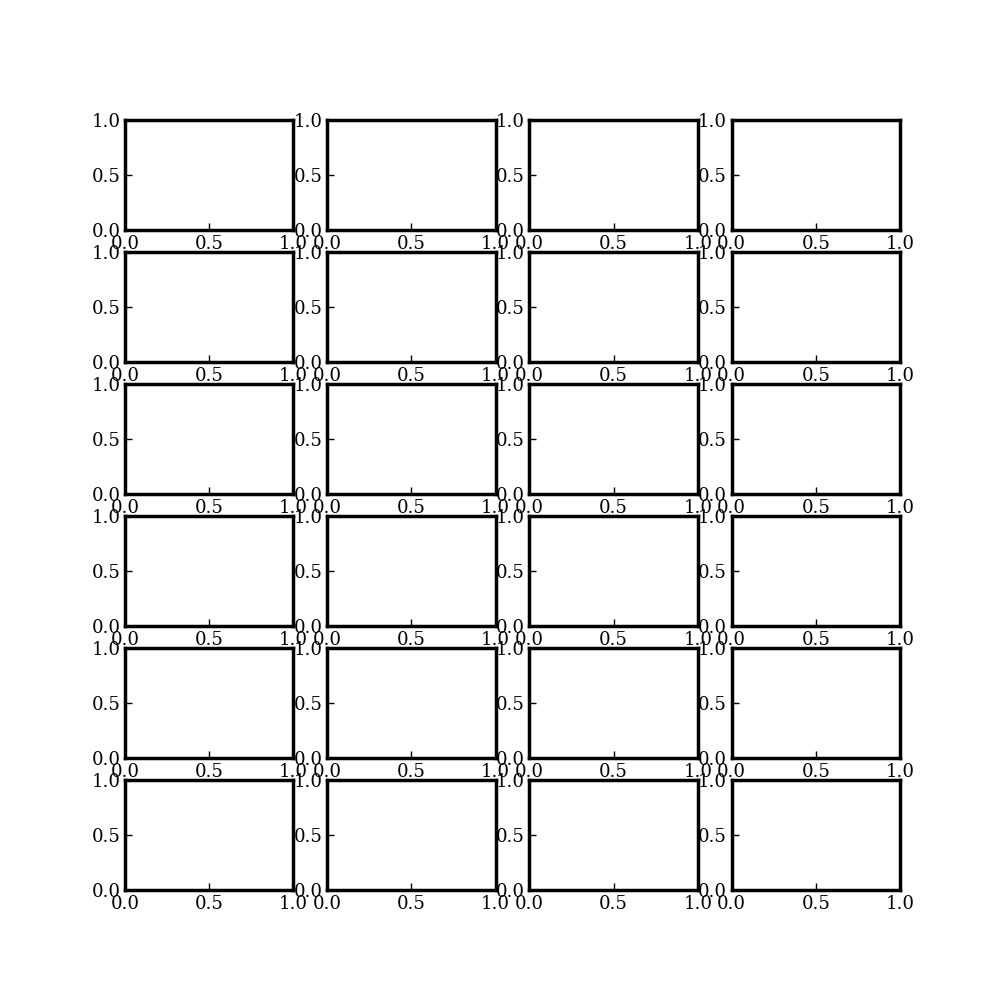

In [26]:
# Vertical offsets: main source = 0, comparisons = +5, +10, …
_offsets = [0] + [5 * (i + 1) for i in range(len(comp_stacks))]

n_rows = int(np.ceil(nstacks / MOSAIC_COLS))
fig_cmp, ax_cmp = plt.subplots(n_rows, MOSAIC_COLS, figsize=(10, 10))
ax_flat = np.array(ax_cmp).flatten()


In [27]:
for ks in range(nstacks):
    nmin, nmax = qbounds[ks]
    N   = 0.5 * (nmin + nmax)
    ax  = ax_flat[ks]
    ax.clear()

    central_freq = (
        0.5 * (tools.line_freq(nmin) + tools.line_freq(nmax))
    ).to(u.MHz)

    # ── Main source (offset = 0) ──────────────────────────────────────────
    line_rb, xaxis = tools.rebinning(STACKS[ks], FREF, REBIN_FACTOR)
    ax.step(xaxis, line_rb * OG + _offsets[0], c=COLOUR,
            label=f'{SOURCE}{_off_str}')

    # ── Comparison pointings ──────────────────────────────────────────────
    for i, (lbl, col, arr) in enumerate(comp_stacks):
        line_rb_c, _ = tools.rebinning(arr[ks], FREF, REBIN_FACTOR)
        ax.step(xaxis, line_rb_c * OG + _offsets[i + 1], c=col, label=lbl)

    # ── Panel formatting ──────────────────────────────────────────────────
    # y-limits scale with the number of overlaid spectra
    _ylim_top = 7.5 + 5 * len(comp_stacks)
    ax.set_ylim(-7.5, _ylim_top)
    ax.text(
        0.05, 0.95,
        f'C$\\alpha$({int(N)})\n{central_freq:.2f}',
        transform=ax.transAxes, fontsize=10,
        va='top', ha='left'
    )
    graphics.set_axes(ax)
    if ks % MOSAIC_COLS > 0:
        ax.set_yticklabels([])
    # Only hide x labels for rows that are not the last complete row
    _last_full_row_start = (nstacks // MOSAIC_COLS - 1) * MOSAIC_COLS
    if _last_full_row_start > 0 and ks < _last_full_row_start:
        ax.set_xticklabels([])

for ax in ax_flat[nstacks:]:
    ax.set_axis_off()

# ── Global legend — adapts whether COMPARISONS is empty or not ────────────
_handles, _labels = [], []
for ax in ax_flat[:nstacks]:
    _h, _l = ax.get_legend_handles_labels()
    for h, l in zip(_h, _l):
        if l not in _labels:
            _handles.append(h)
            _labels.append(l)

if _labels:
    fig_cmp.legend(
        _handles, _labels,
        loc='lower center', ncol=max(1, len(_labels)),
        bbox_to_anchor=(0.5, -0.04), fontsize=11, frameon=False
    )

fig_cmp.tight_layout()
fig_cmp.subplots_adjust(wspace=0, hspace=0)
fig_cmp.supylabel(r'$\tau \times 10^{-4}$ + offset')
fig_cmp.supxlabel(r'Doppler shift $f - f_{n+1 \to n}$')
fig_cmp.suptitle(f'{SOURCE}{_off_str}  |  comparison', fontsize=13, y=1.01)


Text(0.5, 1.01, 'CAS_A  |  comparison')

In [28]:
fig_cmp.savefig(f'{PATH_PDF}{SOURCE}{_off_str}-comparison-with-offsets.pdf', bbox_inches='tight')
print(f'Fit mosaic saved → {PATH_PDF}{SOURCE}{_off_str}-comparison-with-offsets.pdf')


Fit mosaic saved → ../figures/Line-fitting/CAS_A-comparison-with-offsets.pdf


---
## 5 — ⚙️ Voigt fit configuration
**/!\ Edit this cell** 

Each profile is a sum of *N* Voigt components.  Parameters are packed as `[c0, a0, lw0, gw0,  c1, a1, lw1, gw1, …]`:

| Symbol | Meaning |
|--------|---------|
| `c` | Centre frequency offset [MHz] |
| `a` | Amplitude (positive — we fit `−voigt`) |
| `lw` | Lorentzian half-width [MHz] |
| `gw` | Gaussian half-width [MHz] |


### Lorentzian regime threshold

Line are modeled by a Voigt profile (convolution product of Lorentzian and Gaussian profiles)

| Variable | Type | Description |
|---|---|---|
| `N_CRIT` | `int` | Principal quantum number separating the Doppler/Lorentzian regime (low-n, thermal broadening dominates) from the Lorentzian regime (high-n, collisional broadening dominates). |   

N.B: Doppler (resp. Lorentzian) regime **does not** mean that the other component is null. It means it is less prominent.

---

### Fit segments

Each entry in `FIT_SEGMENTS` defines the fit parameters applied to all stacks whose mean principal quantum number N falls in the range `[n_max of previous segment, n_max[`.
Segments are evaluated in order; the first match is used.  
Use this to set case separation of the fitting strategies.

| Key | Type | Description |
|---|---|---|
| `n_max` | `float` | Upper bound on N for this segment (exclusive). Use `np.inf` for the last segment. |
| `velos` | `list[float]` | Initial velocity guess for each Voigt component [km/s]. The number of elements sets the number of fitted components. |
| `dvelos` | `float` or `list[float]` | Half-search window around each velocity guess [km/s]. A scalar applies the same window to all components. |
| `width_max_kms` | `float` | Maximum allowed HWHM for both the Lorentzian (`lw`) and Gaussian (`gw`) width parameters [km/s]. Initial guesses are set to `width_max_kms / 2` (lw) and `width_max_kms / 4` (gw). |
| `amp_min_frac` | `float` | Amplitude lower bound as a fraction of `OG` (e.g. `0.01` → `OG / 100`). |
| `amp_max_frac` | `float` | Amplitude upper bound as a fraction of `OG` (e.g. `1.0` → `OG`). The initial guess is set to the midpoint. |

> N.B.: sometimes the bound parameters for quantum nb *n* should depend on the fit results of quantum nb *n-1*.   
> In this case adjust the bound parameters directly in the loop (see below)


---

### Shared parameters

| Variable | Type | Description |
|---|---|---|
| `FIT_RMS` | `bool` | If `True`, weight the fit by the inverse of the wing noise standard deviation (`sigma` argument of `curve_fit`). |
| `WING_FRAC` | `float` | Fraction of the spectrum used as wings on each side to estimate the noise level. The central portion `[WING_FRAC : 1 − WING_FRAC]` is masked before computing the standard deviation. Default `1/6`. |
| `MAXFEV` | `int` | Maximum number of function evaluations passed to `curve_fit`. Increase if fits fail to converge on noisy stacks. |

In [29]:
# =============================================================================
#  ⚙️  VOIGT FIT CONFIGURATION  —  edit here, do not touch anything below
# =============================================================================

# --- Lorentzian regime threshold ----------------------------------------------
# Below N_CRIT : thermally/turbulently broadened regime → full Voigt fit
# Above N_CRIT : collisional broadening dominates       → restricted search
N_CRIT = 700

# --- Fit segments -------------------------------------------------------------
# List of dicts defining fit parameters per range of principal quantum number N.
# Segments are evaluated in order; the first one with N < n_max is used.
#
# Required keys:
#   n_max         : (float) upper bound on N (exclusive). Use np.inf for the
#                   last segment to cover all remaining stacks.
#   velos         : (list of float) initial velocity guess per component [km/s]
#   dvelos        : (float or list) half-search window per component [km/s]
#   width_max_kms : (float) maximum allowed lw and gw HWHM [km/s]
#   amp_lo  : (float) amplitude lower bound
#   amp_hi  : (float) amplitude upper bound
#
# Display keys (used in the mosaic plot for each segment):
#   xlim          : (tuple) velocity axis limits [km/s], e.g. (-150, 50)
#   ylim          : (tuple) optical-depth axis limits [τ × 10⁻³], e.g. (-5.5, 0.5)
#   comp_colours  : (list of str) one colour per Voigt component, in the same
#                   order as velos.  The residual is always plotted in gray.

# --- Width propagation between consecutive stacks ----------------------------
# When fitting the mid-n and high-n stacks, the width parameters of the
# previous stack can be used to constrain the bounds of the current one.
# This stabilises the fit in the Lorentzian regime where the profile shape
# evolves smoothly with N.
#
# For each segment, set 'propagate_widths' to True to enable this behaviour.
# When enabled, the bounds for lw and gw of each component are computed as:
#
#   lw : [LW_PROP_LO × lw_prev × (f_prev / f_curr),
#          LW_PROP_HI × lw_prev × (f_prev / f_curr)]
#        The (f_prev / f_curr) correction accounts for the frequency scaling
#        of collisional broadening (lw ∝ 1/f).
#
#   gw : [GW_PROP_LO × gw_prev,
#          GW_PROP_HI × gw_prev]
#        No frequency correction: thermal/turbulent broadening does not
#        depend on the observing frequency.
#
# These bounds are only applied from the second stack of the segment onward
# (no previous result exists for the first stack).
#
# Tolerance factors — applied to all segments that use propagation:
LW_PROP_LO = 0.9   # Lower tolerance on lw  (fraction of previous value)
LW_PROP_HI = 2.0   # Upper tolerance on lw
GW_PROP_LO = 0.9   # Lower tolerance on gw  (fraction of previous value)
GW_PROP_HI = 1.1   # Upper tolerance on gw  (tight: gw varies little with N)

# Add 'propagate_widths': True/False to each segment in FIT_SEGMENTS:

# ----------------- THESE PARAMETERS ARE ADAPTED TO CAS A ---------------------
FIT_SEGMENTS = [
    {   # Low-n stacks: narrow search, tight velocity window
        'n_max'        : 560,
        'velos'        : [-47.0, -38.0, 0.],   # 3 components [km/s]
        'dvelos'       : [3.0,   2.0,  2.0],
        'width_max_kms': 100.0,
        'amp_lo' : 0.0,
        'amp_hi' : 1.0,
        'xlim'         : (-100, 100),    # [km/s]
        'ylim'         : (-5.5, 0.5),    # [τ × 10⁻³]
        'comp_colours' : ['blue', 'green', 'red'],
        "regime" : "Doppler",
        'propagate_widths': False,
        
    },
    {   # Mid-n stacks: intermediate width allowed, Lorentzian constraints
        'n_max'        : N_CRIT,
        'velos'        : [-47.0, -38.0, 0.],
        'dvelos'       : [3.0,   2.0,  2.0],
        'width_max_kms': 200.0,
        'amp_lo' : 0.0,
        'amp_hi' : 1.0,
        'xlim'         : (-270, 270),
        'ylim'         : (-5.5, 0.5),
        'comp_colours' : ['blue', 'green', 'red'],
        'propagate_widths': True,
        'regime' : 'Lorentz',
    },
    {   # High-n stacks: single component, wide Lorentzian wings
        'n_max'        : np.inf,
        'velos'        : [-47.0],
        'dvelos'       : 20.0,
        'width_max_kms': 400.0,
        'amp_lo' : 0.01/OG,
        'amp_hi' : 1.0,
        'xlim'         : (-310, 310),
        'ylim'         : (-5.5, 0.5),
        'comp_colours' : ['blue'],
        'regime' : "Lorentz",
        'propagate_widths': True,
    },
]
comp_colours = ['blue', 'green', 'red']
# --- Parameters shared across all segments ------------------------------------
FIT_RMS   = True    # True → weight the fit by the wing noise estimate
WING_FRAC = 1 / 6   # Fraction of the spectrum used as wings on each side
                     # to estimate the noise level; central 2/3 is masked
MAXFEV    = 10000   # Maximum number of function evaluations for curve_fit

# --- Result storage -----------------------------------------------------------
# Maximum number of Voigt components across all segments — sets array width.
# Auto-computed: do not edit.
_MAX_COMP = max(len(s['velos']) for s in FIT_SEGMENTS)

# =============================================================================
#  Segment selector — auto-built, do not edit
# =============================================================================
def _get_fit_params(N):
    """Return the fit parameter dict for the segment that covers N."""
    for seg in FIT_SEGMENTS:
        if "width_max_kms_lw" not in seg.keys():
            seg["width_max_kms_lw"] = None
        if "width_max_kms_gw" not in seg.keys():
            seg["width_max_kms_gw"] = None
        if "width_min_kms_lw" not in seg.keys():
            seg["width_max_kms_lw"] = None
        if "width_min_kms_gw" not in seg.keys():
            seg["width_max_kms_gw"] = None
            
        if "regime" not in seg.keys():
            seg["regime"] = "Lorentz"
        if N < seg['n_max']:
            return seg
    return FIT_SEGMENTS[-1]

print('Fit configuration loaded')
print(f'  N_CRIT    : {N_CRIT}')
print(f'  Segments  : {len(FIT_SEGMENTS)}')
for i, s in enumerate(FIT_SEGMENTS):
    n_lo = FIT_SEGMENTS[i-1]['n_max'] if i > 0 else 0
    n_hi = s['n_max'] if s['n_max'] != np.inf else '∞'
    print(f'    [{i}]  N ∈ [{n_lo}, {n_hi}[   '
          f'velos={s["velos"]}  dvelos={s["dvelos"]}  '
          f'width_max={s["width_max_kms"]} km/s')

Fit configuration loaded
  N_CRIT    : 700
  Segments  : 3
    [0]  N ∈ [0, 560[   velos=[-47.0, -38.0, 0.0]  dvelos=[3.0, 2.0, 2.0]  width_max=100.0 km/s
    [1]  N ∈ [560, 700[   velos=[-47.0, -38.0, 0.0]  dvelos=[3.0, 2.0, 2.0]  width_max=200.0 km/s
    [2]  N ∈ [700, ∞[   velos=[-47.0]  dvelos=20.0  width_max=400.0 km/s


---
## 6 — Fit Voigt profile on each stack

Voigt profiles are fitted on the **main source** stacks only.
Results are stored in three arrays (one row per stack, two columns per
Voigt component — `[value, uncertainty]`):

| Array | Shape | Content |
|-------|-------|---------|
| `CENT` | `(nstacks−1, 2×N_comp)` | Centre [km/s] |
| `WIDT` | `(nstacks−1, 2×N_comp)` | FWHM [Hz] |
| `AREA` | `(nstacks−1, 2×N_comp)` | Integrated area [Hz] |


In [30]:
### COMPUTATION
# Result arrays — columns: [value, uncertainty] × _MAX_COMP
CENT = np.full((nstacks - 1, 2 * _MAX_COMP), np.nan)
AREA = np.full((nstacks - 1, 2 * _MAX_COMP), np.nan)
WIDT = np.full((nstacks - 1, 2 * _MAX_COMP), np.nan)
QUAN = np.zeros(nstacks - 1)

# Results tables - lines and frequency
RESIDUALS = []
FITLINE   = []

# State carried between iterations for width propagation
_prev_lw        = None   # list of lw values from the previous stack [GHz]
_prev_gw        = None   # list of gw values from the previous stack [GHz]
_prev_freq      = None   # central frequency of the previous stack [MHz]
_prev_seg_n_max = None   # n_max of the segment used for the previous stack

for ks in range(nstacks - 1):
    nmin, nmax   = qbounds[ks]
    N            = 0.5 * (nmin + nmax)
    QUAN[ks]     = N
    central_freq = (
        0.5 * (tools.line_freq(nmin) + tools.line_freq(nmax))
    ).to(u.MHz)

    seg = _get_fit_params(N)

    # ── Prepare spectrum ──────────────────────────────────────────────────
    Line0       = STACKS[ks] * OG
    Line, xaxis = tools.rebinning(Line0, FREF, REBIN_FACTOR)
    Velo        = np.array([tools.f_to_v(f, central_freq.value).to(u.km/u.s).value
                             for f in xaxis])


    # ── Width bounds from previous stack (if applicable) ──────────────────
    # Propagation is activated when:
    #   (1) the segment requests it,
    #   (2) a previous result exists,
    #   (3) we are still in the same segment (reset on segment change).
    use_propagation = (
        seg['propagate_widths']
        and _prev_lw is not None
        and seg['n_max'] == _prev_seg_n_max
    )

    if use_propagation:
        # lw scales as 1/f : correct for the frequency shift between stacks
        f_ratio = _prev_freq / central_freq.value
        # Convert previous widths from MHz to km/s for fit_stack input
        # v_to_f is monotone decreasing → use abs to get positive km/s values
        lw_prev_kms = [abs(tools.f_to_v(lw, central_freq.value).to(u.km/u.s).value)
                       for lw in _prev_lw]
        gw_prev_kms = [abs(tools.f_to_v(gw, central_freq.value).to(u.km/u.s).value)
                       for gw in _prev_gw]
        # One pair of bounds per component; None for extra components
        # (fit_stack applies the same width_min/max to all components,
        #  so we use the first component as the reference — adjust if needed)
        lw_min_kms = LW_PROP_LO * lw_prev_kms[0] * f_ratio
        lw_max_kms = LW_PROP_HI * lw_prev_kms[0] * f_ratio
        gw_min_kms = GW_PROP_LO * gw_prev_kms[0]
        gw_max_kms = GW_PROP_HI * gw_prev_kms[0]
    else:
        lw_min_kms = None
        lw_max_kms = seg['width_max_kms']
        gw_min_kms = None
        gw_max_kms = seg['width_max_kms']

    # ── Fit ───────────────────────────────────────────────────────────────
    popt, pcov = line_fitting.fit_stack(
        spectrum         = Line,
        freq_axis        = xaxis,
        central_freq     = central_freq.value,
        velos            = seg['velos'],
        dvelos           = seg['dvelos'],
        amp_lo           = seg['amp_lo'],
        amp_hi           = seg['amp_hi'],
        width_max_kms_lw = lw_max_kms,
        width_min_kms_lw = lw_min_kms,
        width_max_kms_gw = gw_max_kms,
        width_min_kms_gw = gw_min_kms,
        og               = OG,
        rms              = FIT_RMS,
        wing_fraction    = WING_FRAC,
        maxfev           = MAXFEV,
        regime           = seg['regime'],
    )

    # ── Store widths for next iteration ───────────────────────────────────
    _prev_lw        = [popt[4*kv+2] for kv in range(len(seg['velos']))]
    _prev_gw        = [popt[4*kv+3] for kv in range(len(seg['velos']))]
    _prev_freq      = central_freq.value
    _prev_seg_n_max = seg['n_max']


    # ── Per-component results and overlays ────────────────────────────────
    n_comp_eff = len(seg['velos'])
    Y_total    = np.zeros_like(Velo)
    Y_COMP = []
    for kv in range(n_comp_eff):
        c0,  a0,  lw0,  gw0  = popt[4*kv : 4*(kv+1)]
        dc0, da0, dlw0, dgw0 = np.sqrt(np.diag(pcov))[4*kv : 4*(kv+1)]

        y_comp  = line_fitting.profile(xaxis, c0, a0, lw0, gw0, og=OG)
        Y_total += y_comp
        #colour  = seg['comp_colours'][kv]
        #ax.plot(Velo, y_comp * 1e3, c=colour, ls=_linestyles[kv % 3])

        wV  = line_fitting.voigt_fwhm(gw0, lw0)                  * 1e6
        dwV = line_fitting.voigt_fwhm_error(dlw0, dgw0, lw0, gw0)  * 1e6
        WIDT[ks, 2*kv : 2*(kv+1)] = wV, dwV

        Ifit  = np.nansum(-y_comp/OG) * (_df * REBIN_FACTOR) * 1e6
        dIfit = Ifit * (dwV / wV) if wV != 0 else 0.0
        AREA[ks, 2*kv : 2*(kv+1)] = Ifit, dIfit

        center  =  tools.f_to_v(c0,  central_freq.value).to(u.km/u.s).value
        dcenter = -tools.f_to_v(dc0, central_freq.value).to(u.km/u.s).value
        CENT[ks, 2*kv : 2*(kv+1)] = center, dcenter
        Y_COMP.append(y_comp)
    # ── Residual ──────────────────────────────────────────────────────────
    residual = Line - Y_total
    # ax.step(Velo, residual, c='gray', ls='--', lw=0.8, where='mid')
    RESIDUALS.append(residual)
    FITLINE.append(Y_COMP)

_mask       = AREA < 1e-8
WIDT[_mask] = np.nan
CENT[_mask] = np.nan
AREA[_mask] = np.nan

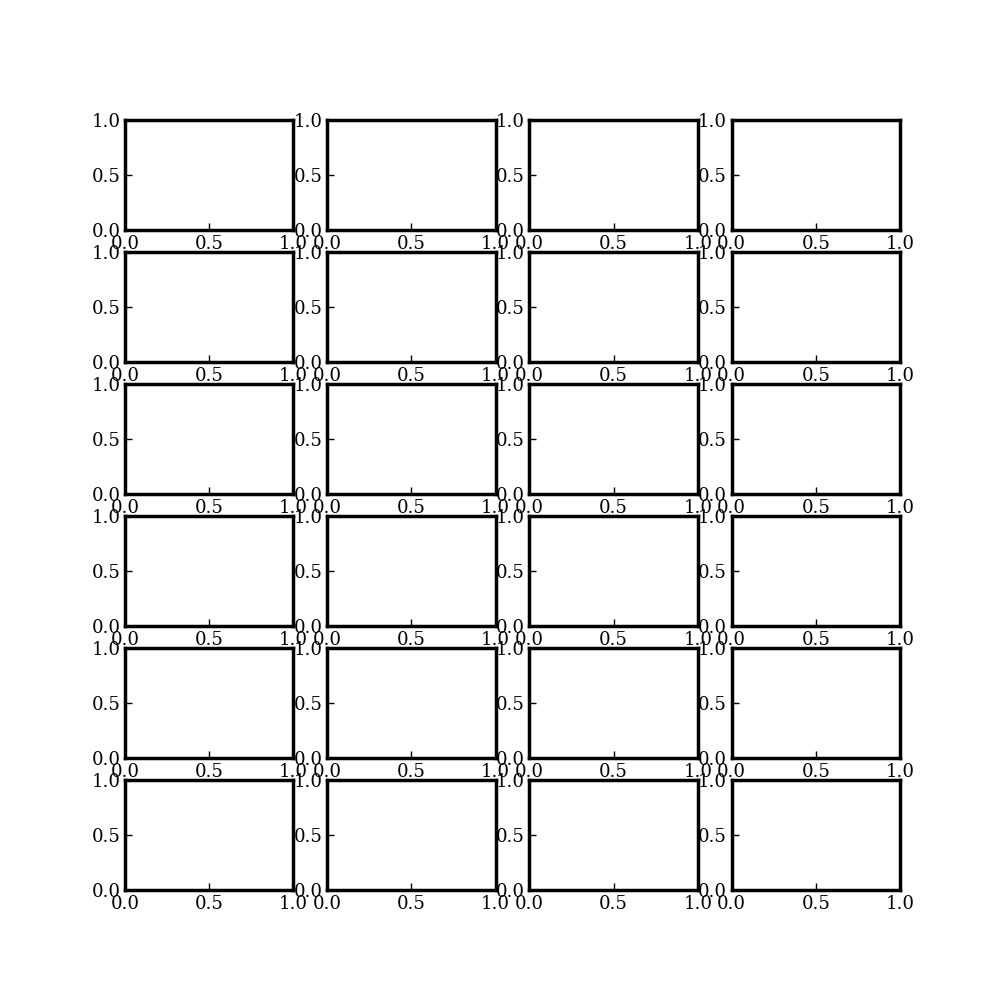

In [31]:
### VISUALISATION

n_comp     = len(VELOS)
n_rows_fit = int(np.ceil((nstacks - 1) / MOSAIC_COLS))

fig_fit, ax_fit = plt.subplots(n_rows_fit, MOSAIC_COLS, figsize=(10, 10))
ax_flat_fit     = np.array(ax_fit).flatten()
_linestyles     = ['solid', 'dashed', 'dotted']


In [32]:
ylim = (-4.5,2)

for ks in range(nstacks - 1):
    # ── Retrieve data ─────────────────────────────────────────────────────────
    
    nmin, nmax   = qbounds[ks]
    N            = 0.5 * (nmin + nmax)
    central_freq = (
        0.5 * (tools.line_freq(nmin) + tools.line_freq(nmax))
    ).to(u.MHz)

    seg = _get_fit_params(N)

    # ── Prepare spectra ──────────────────────────────────────────────────
    Line0       = STACKS[ks] * OG
    Line, xaxis = tools.rebinning(Line0, FREF, REBIN_FACTOR)
    Velo        = np.array([tools.f_to_v(f, central_freq.value).to(u.km/u.s).value
                             for f in xaxis])
    fitlines = FITLINE[ks]
    residuals = RESIDUALS[ks]
    
    ax = ax_flat_fit[ks]
    ax.clear()
    graphics.set_axes(ax)
    ax.step(Velo, Line, c='k', label=f'{SOURCE}{_off_str}')
    
    for kv in range(len(seg["velos"])):

        colour  = seg['comp_colours'][kv]
        ax.plot(Velo, fitlines[kv], c=colour, ls=_linestyles[kv % 3])
        
    ax.step(Velo, residual, c='gray', ls='--', lw=0.8, where='mid')

    ax.set_xlim(seg['xlim'])
    ax.set_ylim(ylim)
    ax.text(
        0.05, 0.95,
        f'C$\\alpha$({int(N)})\n{central_freq:.2f}',
        transform=ax.transAxes, fontsize=10, va='top',
    )
    
    if ks % MOSAIC_COLS > 0:
        ax.set_yticklabels([])
    _last_full_row_start = (nstacks // MOSAIC_COLS - 1) * MOSAIC_COLS
    if _last_full_row_start > 0 and ks < _last_full_row_start:
        ax.set_xticklabels([])

for ax in ax_flat_fit[nstacks - 1:]:
    ax.set_axis_off()


fig_fit.tight_layout()
fig_fit.subplots_adjust(wspace=0, hspace=0)
fig_fit.supxlabel(r'Doppler shift $f - f_{n+1 \to n}$')
fig_fit.supylabel(r'$\tau \times 10^{-4}$')
fig_fit.suptitle(f'{SOURCE}{_off_str}  |  Voigt fits', fontsize=13, y=1.01)


Text(0.5, 1.01, 'CAS_A  |  Voigt fits')

In [33]:
fig_fit.savefig(f'{PATH_PDF}{SOURCE}{_off_str}-detections.pdf', bbox_inches='tight')
print(f'Fit mosaic saved → {PATH_PDF}{SOURCE}{_off_str}-detections.pdf')


Fit mosaic saved → ../figures/Line-fitting/CAS_A-detections.pdf


---
## 7 — Line-centre histogram

Distribution of fitted line centres [km/s] for the $i^{th}$ Voigt component.
A narrow distribution near one $v_{centroid}$ indicates a consistent velocity across
the full quantum-number range.


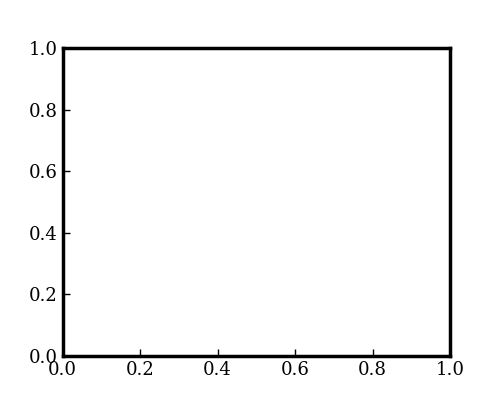

In [34]:
fig_hist, ax_hist = plt.subplots(figsize=(5, 4))



In [35]:
kv   = 1 # Voigt component index to plot
colour = comp_colours[kv]
bins = np.arange(np.nanmin(CENT[:, 2*kv])-5, np.nanmax(CENT[:, 2*kv])+5, 1)

ax_hist.clear()
graphics.set_axes(ax_hist)
ax_hist.hist(CENT[:, 2*kv], color=colour, bins=bins)
ax_hist.set_xlabel('Centre (km/s)')
ax_hist.set_ylabel('Number of stacks')
ax_hist.set_title(f'{SOURCE}{_off_str}  —  component {kv}')
fig_hist.tight_layout()


In [36]:
fig_hist.savefig(f'{PATH_PDF}{SOURCE}{_off_str}-centre-hist.pdf', bbox_inches='tight')
print(f'Histogram saved → {PATH_PDF}{SOURCE}{_off_str}-centre-{kv}-hist.pdf')


Histogram saved → ../figures/Line-fitting/CAS_A-centre-1-hist.pdf


---
## 8 — Weighted mean line centre

Inverse-variance weighted average and standard deviation of the fitted centres.
Unconverged stacks (NaN) are automatically excluded.


In [37]:

for kv in range(n_comp) :
    centres = CENT[:, 2*kv]
    errors  = CENT[:, 2*kv + 1]
    
    _valid        = np.isfinite(centres) & np.isfinite(errors) & (errors > 0)
    weights       = 1.0 / errors[_valid]**2
    mean_w, std_w = tools.weighted_avg_and_std(centres[_valid], weights)
    
    print(f'Component {kv} — weighted mean centre : {mean_w:+.2f} km/s')
    print(f'Component {kv} — weighted std dev     :  {std_w:.2f} km/s')
    print(f'({_valid.sum()} / {len(centres)} stacks used)')


Component 0 — weighted mean centre : -48.28 km/s
Component 0 — weighted std dev     :  0.61 km/s
(22 / 22 stacks used)
Component 1 — weighted mean centre : -38.54 km/s
Component 1 — weighted std dev     :  0.38 km/s
(18 / 22 stacks used)
Component 2 — weighted mean centre : -1.43 km/s
Component 2 — weighted std dev     :  0.54 km/s
(16 / 22 stacks used)


---
## 9 — Fit parameters vs quantum number n

Three panels per Voigt component:
1. **Centre** [km/s]
2. **FWHM** [Hz] (log scale)
3. **Integrated area** [Hz]

Horizontal error bars show the half-width of each quantum-number bin.


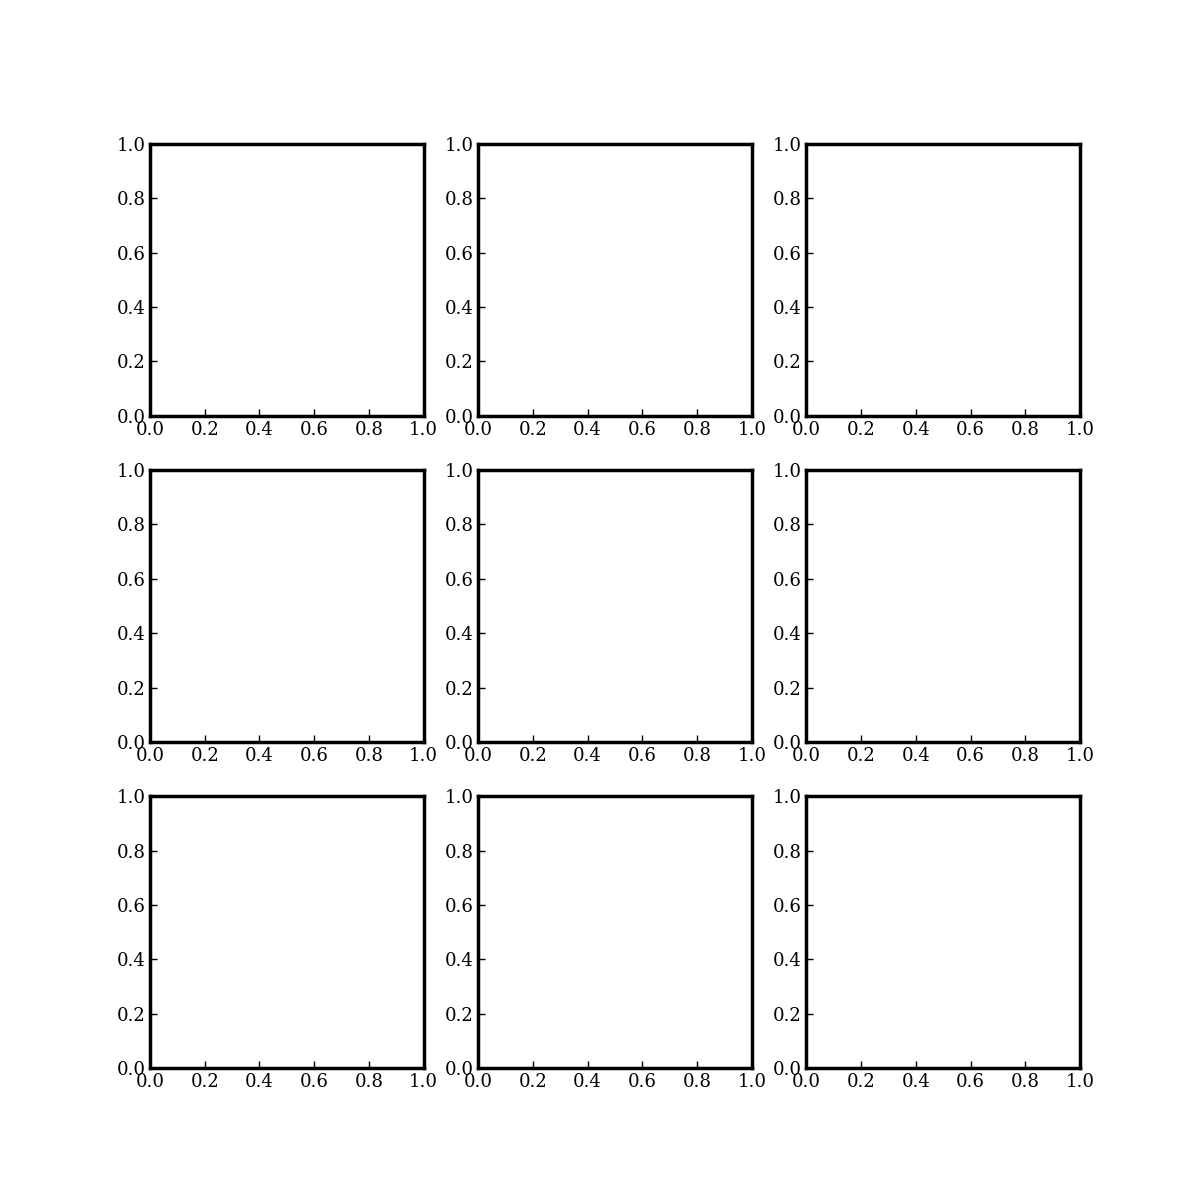

In [38]:
XERR  = (qbounds[:-1, 1] - qbounds[:-1, 0]) / 2
_fmts = ['.', 's', '^']

figp, sbplot = plt.subplots(n_comp, 3, figsize=(12, 4 * n_comp),
                            squeeze=False)


In [39]:

for kv in range(n_comp):
    axc, axw, axa = sbplot[kv]

    for ax in [axc, axw, axa]:
        ax.clear()
        graphics.set_axes(ax)

    axc.errorbar(QUAN, CENT[:, 2*kv], yerr=CENT[:, 2*kv+1], xerr=XERR,
                 fmt=_fmts[kv], color=comp_colours[kv])
    axc.set_title('Centre (km/s)')
    axc.set_xlabel('Quantum number n')
    axc.set_xlim(400, 850)
    # axc.set_ylim(-50, 0)

    axw.semilogy()
    axw.errorbar(QUAN, WIDT[:, 2*kv], yerr=WIDT[:, 2*kv+1], xerr=XERR,
                 fmt=_fmts[kv], color=comp_colours[kv])
    axw.set_title('FWHM (Hz)')
    axw.set_xlabel('Quantum number n')
    axw.set_xlim(400, 850)
    # axw.set_ylim(5e1, 1e3)

    axa.errorbar(QUAN, AREA[:, 2*kv], yerr=AREA[:, 2*kv+1], xerr=XERR,
                 fmt=_fmts[kv], color=comp_colours[kv])
    axa.set_title('Integrated area (Hz)')
    axa.set_xlabel('Quantum number n')
    axa.set_xlim(400, 850)
    # axa.set_ylim(-1, 4)

figp.suptitle(f'{SOURCE}{_off_str}  —  fit parameters', fontsize=13)
figp.tight_layout()


In [40]:
figp.savefig(f'{PATH_PDF}{SOURCE}{_off_str}-fit-params.pdf', bbox_inches='tight')
print(f'Parameter plot saved → {PATH_PDF}{SOURCE}{_off_str}-fit-params.pdf')


Parameter plot saved → ../figures/Line-fitting/CAS_A-fit-params.pdf


---
## 10 — Export fit results to CSV

One CSV file per Voigt component in `OUTPUT_DIR`.

| Column | Content |
|--------|---------|
| `n` | Mid-interval quantum number |
| `wV` | Voigt FWHM [Hz] |
| `dwV` | FWHM uncertainty [Hz] |
| `Ifit` | Integrated area [Hz] |
| `dIfit` | Area uncertainty [Hz] |
| `CENTER` | Fitted line centre [km/s] |
| `CENTER_err` | Centre uncertainty [km/s] |


In [41]:
Q = np.array([QUAN]).T

for kv in range(n_comp):
    df_out = pd.DataFrame(
        np.concatenate((
            Q,
            WIDT[:, 2*kv : 2*(kv+1)],
            AREA[:, 2*kv : 2*(kv+1)],
            CENT[:, 2*kv : 2*(kv+1)],
        ), axis=1),
        columns=['n', 'wV', 'dwV', 'Ifit', 'dIfit', 'CENTER', 'CENTER_err']
    ).sort_values('n')

    kv_str   = f'-{kv}' if n_comp > 1 else ''
    out_path = os.path.join(
        OUTPUT_DIR,
        f'values_of_fit-{SOURCE}{_off_str}-{n_comp}comp{kv_str}-new.csv'
    )
    df_out.to_csv(out_path, index=False)
    print(f'Saved → {out_path}')


Saved → ../data/fitresults/CAS_A/values_of_fit-CAS_A-3comp-0-new.csv
Saved → ../data/fitresults/CAS_A/values_of_fit-CAS_A-3comp-1-new.csv
Saved → ../data/fitresults/CAS_A/values_of_fit-CAS_A-3comp-2-new.csv
